adopcion de vehiculos electricos y clasificacion de la ansiedad por la autonomia

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


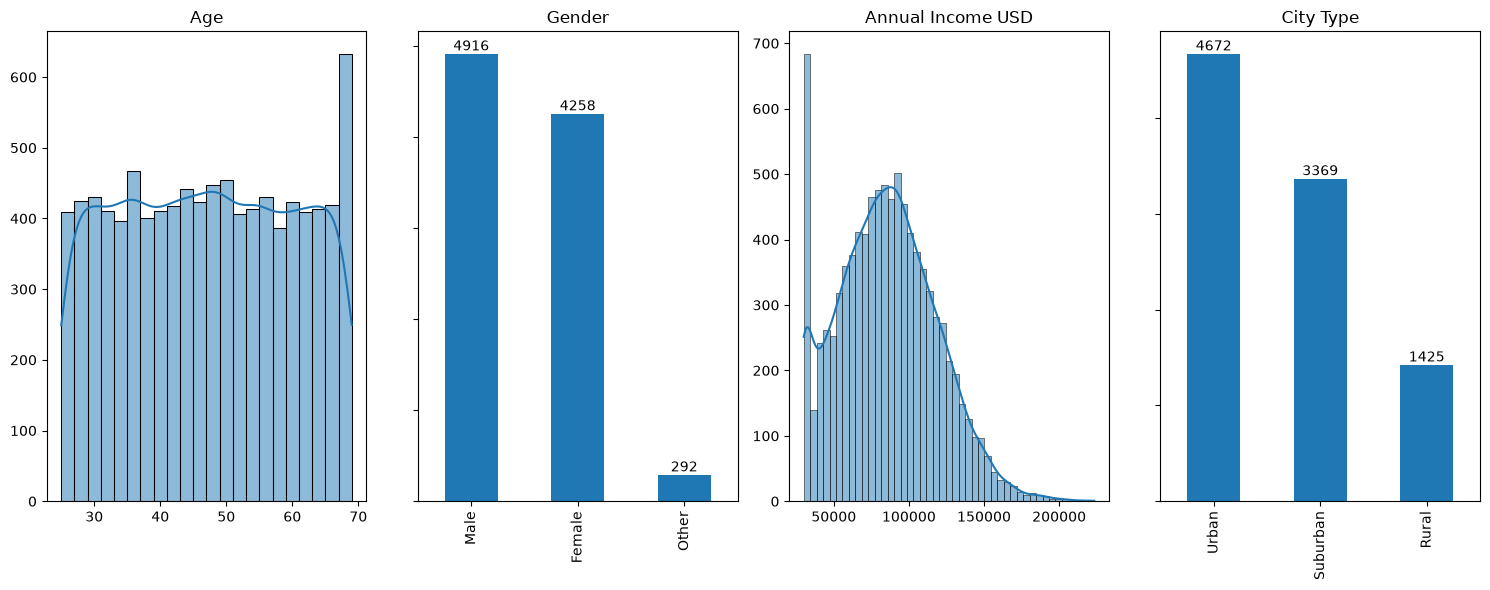

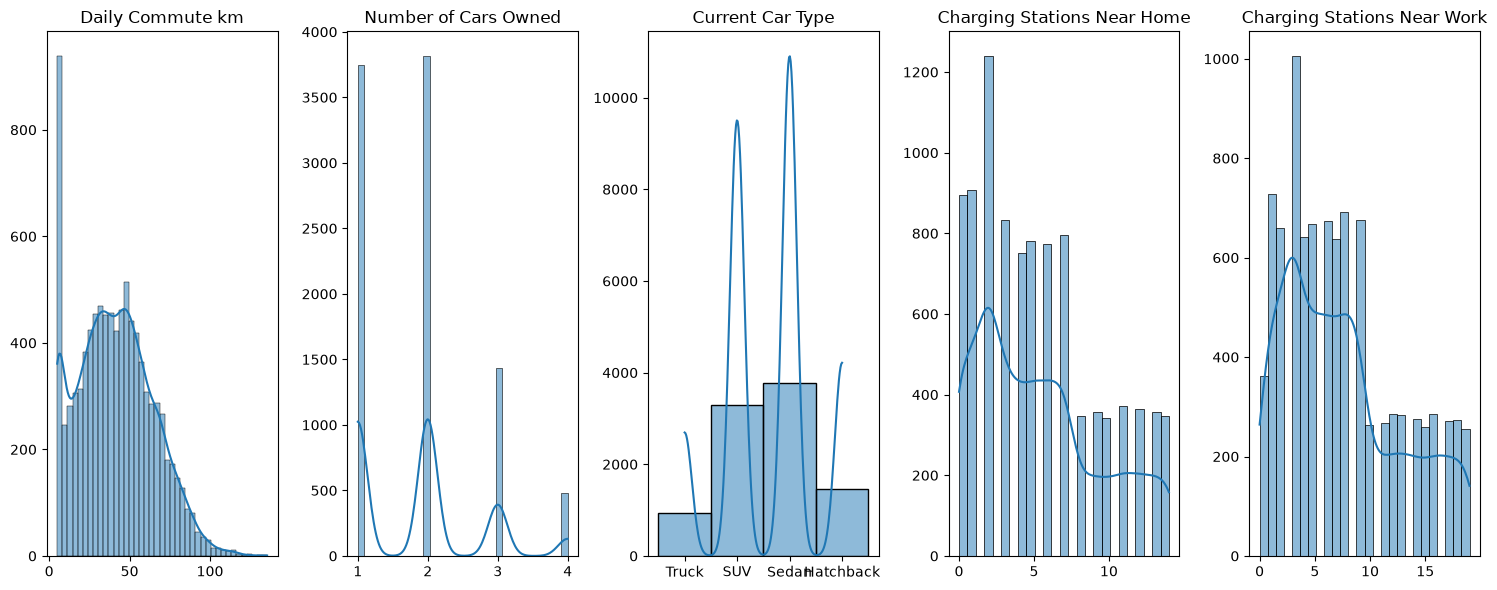

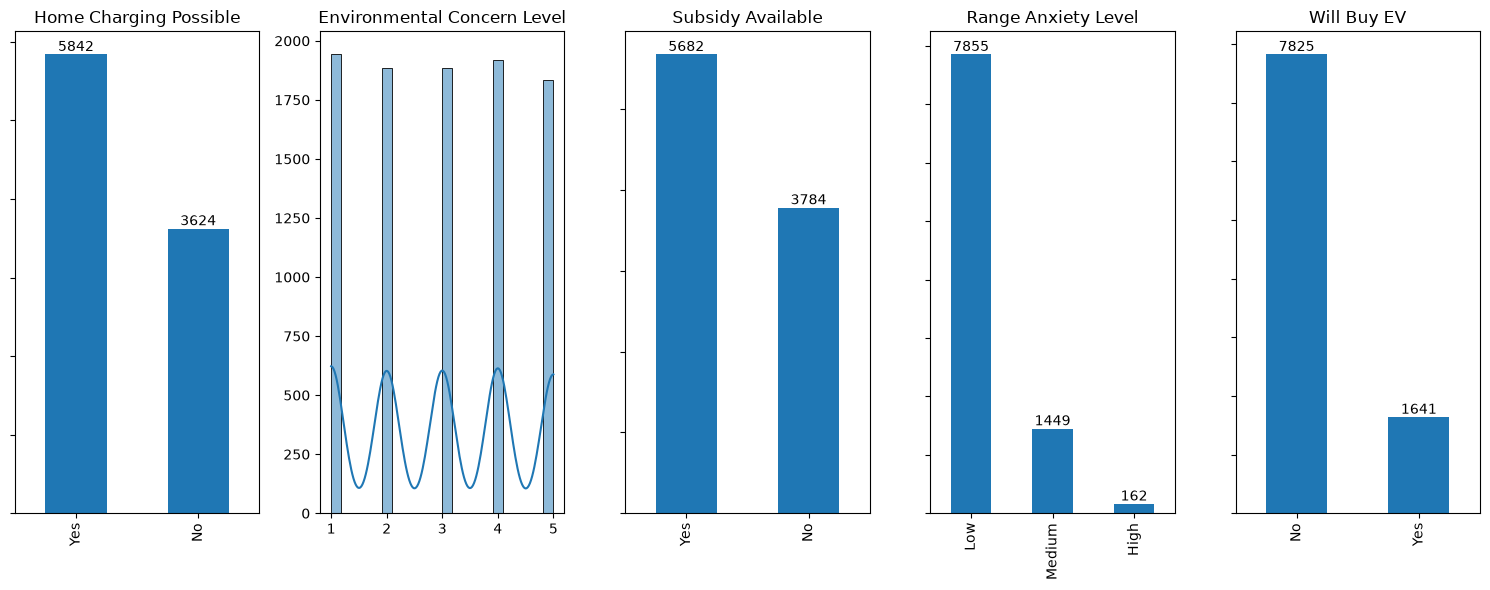

In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import warnings
warnings.filterwarnings("ignore")


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML
from pathlib import Path

def bar_labels(axes, rotation=0, location="edge"):
    for container in axes.containers:
        axes.bar_label(container, label_type=location, rotation=rotation)
    axes.set_xlabel("")
    axes.set_ylabel("")
    axes.set_yticklabels(())

def training_classification():
    rfc = RandomForestClassifier()
    abc = AdaBoostClassifier()
    gbc = GradientBoostingClassifier()
    etc = ExtraTreesClassifier()
    lgr = LogisticRegression()
    svc = SVC()
    xgb = XGBClassifier()
    lgb = LGBMClassifier(verbose=-100)
    cat = CatBoostClassifier(verbose=False)

    models = [rfc, abc, gbc, etc, lgr,
             svc, xgb, lgb, cat]

    names = ["Random Forest", "Ada Boost", "Gradient Boosting", "Extra Trees", "Logistic Regression",
            "SVC", "XGBoost", "LightGBM", "Cat Boost"]

    scores = []
    cms = dict()
    reports = dict()

    sample_weights = compute_sample_weight(
        class_weight='balanced',
        y=y_train #provide your own target name
    )

    for i, j in enumerate(names):
        models[i].fit(x_train, y_train, sample_weight=sample_weights)
        pred = models[i].predict(x_test)
        scores += [accuracy_score(pred, y_test)]
        cms[j] = confusion_matrix(pred, y_test)
        reports[j] = classification_report(pred, y_test)

    dt = pd.DataFrame({"scores": scores}, index=names)
    dt = dt.sort_values("scores", ascending=False)

    dt["scores"] = dt["scores"]*100
    dt["scores"] = round(dt["scores"], 2)

    fig, axes = plt.subplots(figsize=(15, 6))

    dt["scores"].plot(kind="bar", ax=axes)
    bar_labels(axes)

    index = 0

    for _ in range(3):
        fig, axes = plt.subplots(ncols=3, figsize=(15, 6))
        for i in range(3):
            sns.heatmap(cms[dt.index[index]], annot=True, ax=axes[i])
            axes[i].set_title("{}: {}%".format(dt.index[index], dt.iloc[index, 0]))
            index += 1
        plt.tight_layout()
        plt.show()

    for i in dt.index:
        print("*"*30)
        print("\n")
        print(i)
        print("\n")
        print(reports[i])

filename = "EV_Adoption_and_Range_Anxiety_Dataset.csv"

# Search in the notebook's current folder and its subfolders
matches = list(Path.cwd().rglob(filename))

if not matches:
    raise FileNotFoundError(
        f"No se encontró '{filename}'. "
        "Coloca el archivo CSV en la carpeta del notebook."
    )

df = pd.read_csv(matches[0])
display(df.head())

df = df.iloc[:, 1:]

df.dropna(inplace=True)

cats = [i for i in df.columns if df[i].dtype == 'O' or df[i].nunique() <= 3]
nums = [i for i in df.columns if i not in cats]

index = 0

for _ in [4, 5, 5]:
    fig, axes = plt.subplots(ncols=_, figsize=(15, 6))
    for i in range(_):
        if df.columns[index] in cats:
            df[df.columns[index]].value_counts()[:10].plot(kind="bar", ax=axes[i])
            bar_labels(axes[i])
        else:
            sns.histplot(df, x=df.columns[index], kde=True, ax=axes[i])
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")
        axes[i].set_title(df.columns[index].replace('_', ' '))

        index += 1
    plt.tight_layout()
    plt.show()

Vehículos eléctricos comprados: características comunes

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definición de variables categóricas requerida para 'cats'
cats = [col for col in df.columns if df[col].dtype == 'O' or df[col].nunique() <= 3]

index = 0

for _ in [4, 4, 5]:
    fig, axes = plt.subplots(ncols=_, figsize=(15, 6))
    for i in range(_):
        if df.columns[index] in cats:
            df.groupby(df.columns[index])[cats[-1]].value_counts()[:10].unstack().plot(kind="bar", stacked=True, ax=axes[i])
            etiquetar_barras(axes[i], 0, "center") # Cambiado 'bar_labels' por 'etiquetar_barras'
            axes[i].set_title("Count of {}\nfor buyers that\ndecided to buy EV".format(df.columns[index].replace('_', ' ')))
        else:
            sns.kdeplot(df, x=df.columns[index], hue=df.columns[-1], ax=axes[i])
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")
            axes[i].set_title("{}\ndensity distribution for buyers that\ndecided to buy EV".format(df.columns[index].replace('_', ' ')))
        index += 1
    plt.tight_layout()
    plt.show()

NameError: name 'df' is not defined